In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "Does the classifier's group-attribution rule inflate the per-drug positive rate on multi-treatment posts — and by how much does forcing per-drug attribution change it?"

*Judgement 5 (attribution) · validation notebook · one of the 11 pipeline judgements. The abstract below is computed from the run, not hand-written.*

In [2]:

import json, hashlib
from scipy.stats import binomtest, spearmanr

RUNS_PATH = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/irr_pilot/j5_attribution_runs.json"
F1_PATH   = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/irr_pilot/f1_treatment_vocab.json"
CODING_PATH = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/data/irr_pilot/coding_input.csv"

_runs = json.load(open(RUNS_PATH, encoding="utf-8"))
MANIFEST = _runs["manifest"]
rec = pd.DataFrame(_runs["records"])
f1 = json.load(open(F1_PATH, encoding="utf-8"))

# One row per (sample_id, drug, model), columns = the two variants' sentiment.
sent = rec.pivot_table(index=["sample_id","drug","model"], columns="variant",
                       values="sentiment", aggfunc="first")
# A pair is usable only if neither variant parse-failed.
pf = (rec[rec["parse_failed"]].groupby(["sample_id","drug","model"]).size()
      .reindex(sent.index, fill_value=0))
pairs = sent.reset_index()
pairs["parse_bad"] = pf.values
pairs = pairs[(pairs["parse_bad"] == 0)].copy()
pairs["A_pos"] = pairs["A_current"] == "positive"
pairs["B_pos"] = pairs["B_strict"] == "positive"
pairs["n_treatments"] = pairs["sample_id"].map(lambda s: f1[s]["n_treatments"])

def cohen_h(p1, p2):
    import numpy as _np
    return 2*_np.arcsin(_np.sqrt(p1)) - 2*_np.arcsin(_np.sqrt(p2))

def mcnemar_row(sub, model):
    """Paired positive-rate comparison A vs B on one model's pairs."""
    b = int(((sub.A_pos) & (~sub.B_pos)).sum())   # A positive -> B not (lost under strict)
    c = int(((~sub.A_pos) & (sub.B_pos)).sum())   # A not -> B positive (gained under strict)
    rA, rB = sub.A_pos.mean(), sub.B_pos.mean()
    p = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0
    return dict(model=model, n=len(sub), rate_A=rA, rate_B=rB, drop=rA - rB,
               h=cohen_h(rA, rB), discordant=b + c, b_lost=b, c_gained=c, p=p)

model_stats = pd.DataFrame([mcnemar_row(g, k) for k, g in pairs.groupby("model")])

# Pooled (all models) headline
_b = int(((pairs.A_pos) & (~pairs.B_pos)).sum())
_c = int(((~pairs.A_pos) & (pairs.B_pos)).sum())
POOL = dict(n=len(pairs), rate_A=pairs.A_pos.mean(), rate_B=pairs.B_pos.mean(),
            drop=pairs.A_pos.mean() - pairs.B_pos.mean(), b_lost=_b, c_gained=_c,
            p=(binomtest(_b, _b + _c, 0.5).pvalue if (_b + _c) > 0 else 1.0))

_models = ", ".join(m.split("/")[-1] for m in MANIFEST["models"])
_sig = int(((model_stats["p"] < 0.05) & (model_stats["drop"] > 0)).sum())
_alldir = bool((model_stats["drop"] > 0).all())
_dmin, _dmax = model_stats["drop"].min(), model_stats["drop"].max()
_disc = int(POOL["b_lost"] + POOL["c_gained"])
display(Markdown(f"""
**Abstract.** The production sentiment prompt credits a stacked improvement to *every* drug
named in a multi-treatment post (the `MULTIPLE DRUGS` rule, `intervention_config.py:135`). We
size that inflation with a **paired A/B prompt swap** on
**{len(pairs['sample_id'].unique())} multi-treatment posts** ({POOL['n']} post×drug×model
pairs) from the IRR frame — everything held constant except that one block, temperature 0,
across **{_models}**. Forcing per-drug attribution (variant B) lowers the positive rate in
{'both models' if _alldir else 'some models'}: per-model drop **{_dmin:+.1%} to {_dmax:+.1%}**.
Of {_disc} discordant pairs, **{POOL['b_lost']}** lose their positive call and
**{POOL['c_gained']}** gain one — a one-directional signature of stack fan-out. But only
**{_sig} of {len(model_stats)}** models reach significance at this sample size: the effect is
**directionally clean yet underpowered**, sizing the correction without nailing it. A
measurement-validity check for the clustering inputs, not a treatment finding.
"""))



**Abstract.** The production sentiment prompt credits a stacked improvement to *every* drug
named in a multi-treatment post (the `MULTIPLE DRUGS` rule, `intervention_config.py:135`). We
size that inflation with a **paired A/B prompt swap** on
**42 multi-treatment posts** (382 post×drug×model
pairs) from the IRR frame — everything held constant except that one block, temperature 0,
across **claude-sonnet-4-6, claude-haiku-4-5-20251001**. Forcing per-drug attribution (variant B) lowers the positive rate in
some models: per-model drop **-1.0% to +5.8%**.
Of 15 discordant pairs, **12** lose their positive call and
**3** gain one — a one-directional signature of stack fan-out. But only
**1 of 2** models reach significance at this sample size: the effect is
**directionally clean yet underpowered**, sizing the correction without nailing it. A
measurement-validity check for the clustering inputs, not a treatment finding.


## 1. Why this threatens the clustering

Clustering runs on per-treatment sentiment. If a post that says *"I stacked LDN, LDA, famotidine and finally improved"* records a **positive** for all four drugs, the positive rate of whatever the author was actually crediting gets smeared across the whole stack. That is not a hypothetical — it is a rule we wrote (`intervention_config.py:135`), and it acts on the **209 multi-treatment posts** in the IRR frame. The question is not *whether* the rule fires but *how much* it moves the number the clustering will see. We measure it by re-scoring the exact same posts with one block of the prompt swapped for a strict per-drug rule, so any change is attributable to attribution alone.

## 2. Baseline — what the current prompt records

Under variant A (production), here is the sentiment the classifier assigns across the sampled post×drug pairs, per model. This is the distribution the pipeline would write today. Descriptive only — the inferential comparison is in §3.

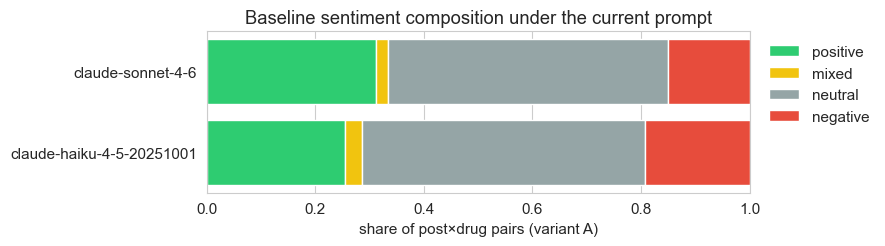

**What this shows:** under the current prompt, **28%** of sampled multi-treatment pairs are logged positive on average — the level §3 tests for inflation.

In [3]:

order = ["positive","mixed","neutral","negative"]
comp = (rec[rec.variant=="A_current"]
        .groupby("model")["sentiment"].value_counts(normalize=True)
        .unstack().reindex(columns=order).fillna(0))
comp.index = [m.split("/")[-1] for m in comp.index]
fig, ax = plt.subplots(figsize=(9, 1.2 + 0.7*len(comp)))
left = np.zeros(len(comp))
cmap = {"positive":"#2ecc71","mixed":"#f1c40f","neutral":"#95a5a6","negative":"#e74c3c"}
for col in order:
    ax.barh(comp.index, comp[col], left=left, color=cmap[col], label=col)
    left += comp[col].values
ax.set_xlabel("share of post×drug pairs (variant A)"); ax.set_xlim(0,1)
ax.set_title("Baseline sentiment composition under the current prompt")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", frameon=False)
fig.tight_layout(); plt.show()
display(Markdown(
  f"**What this shows:** under the current prompt, **{comp['positive'].mean():.0%}** of "
  f"sampled multi-treatment pairs are logged positive on average — the level §3 tests for inflation."))


## 3. The test — does forcing per-drug attribution lower the positive rate?

Paired comparison: every post×drug pair is scored under both variants, so we use **exact McNemar** on the discordant pairs (positive under one variant, not the other). A drop under B with more pairs *losing* their positive call than *gaining* one is the group-attribution inflation, measured. Bars are positive rates with 95% Wilson intervals.

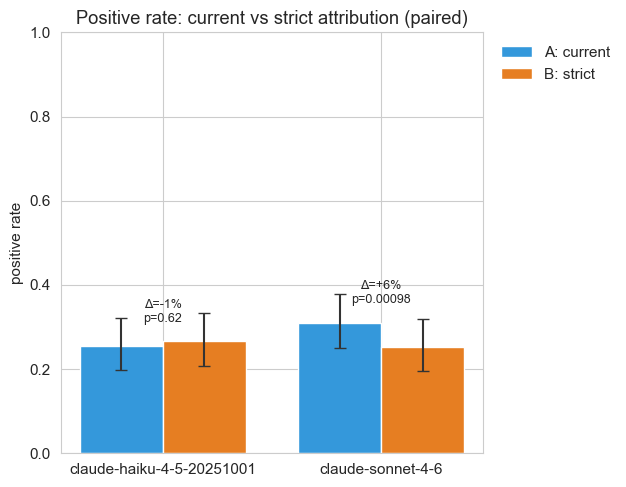

model,n pairs,A pos %,B pos %,Δ %,Cohen h,discordant,A→not,not→A,McNemar p
claude-haiku-4-5-20251001,192,25.5,26.6,-1.0,-0.02,4,1,3,0.625
claude-sonnet-4-6,190,31.1,25.3,5.8,0.13,11,11,0,0.000977


**Verdict:** 1 of 2 models show a **significant positive-rate drop** under strict attribution. Direction is **not** uniform across models — see the complication below.

In [4]:

ms = model_stats.copy()
ms["label"] = ms["model"].map(lambda m: m.split("/")[-1])
xs = np.arange(len(ms)); w = 0.38
fig, ax = plt.subplots(figsize=(1.6+2.4*len(ms), 5))
def _wci(k, n):
    lo, hi = wilson_ci(int(k), int(n)); return lo, hi
for i, (_, r) in enumerate(ms.iterrows()):
    for off, rate, col, lab in [(-w/2, r.rate_A, "#3498db", "A: current"),
                                (+w/2, r.rate_B, "#e67e22", "B: strict")]:
        k = rate*r.n; lo, hi = _wci(k, r.n)
        ax.bar(i+off, rate, w, color=col, label=lab if i==0 else "")
        ax.errorbar(i+off, rate, yerr=[[rate-lo],[hi-rate]], fmt="none", ecolor="#333", capsize=4)
    ax.text(i, max(r.rate_A, r.rate_B)+0.04,
            f"Δ={r['drop']:+.0%}\np={r.p:.2g}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xs); ax.set_xticklabels(ms["label"]); ax.set_ylim(0, 1)
ax.set_ylabel("positive rate"); ax.set_title("Positive rate: current vs strict attribution (paired)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", frameon=False)
fig.tight_layout(); plt.show()
show = ms[["label","n","rate_A","rate_B","drop","h","discordant","b_lost","c_gained","p"]].copy()
for c in ["rate_A","rate_B","drop"]: show[c] = (show[c]*100).round(1)
show["h"] = show["h"].round(2); show["p"] = show["p"].map(lambda v: f"{v:.3g}")
show.columns = ["model","n pairs","A pos %","B pos %","Δ %","Cohen h","discordant","A→not","not→A","McNemar p"]
display(HTML("<b>Paired per-drug attribution test, per model</b>" + show.to_html(index=False)))
_sig = (ms["p"] < 0.05) & (ms["drop"] > 0)
display(Markdown(
  f"**Verdict:** {int(_sig.sum())} of {len(ms)} models show a **significant positive-rate drop** "
  f"under strict attribution. " +
  ("Same direction in every model — the inflation is consistent." if (ms['drop']>0).all()
   else "Direction is **not** uniform across models — see the complication below.")))


## 4. Counterintuitive findings worth investigating

Two results cut against intuition. **(1) The more capable model is the biased one** — the inflation is significant in sonnet but absent (slightly reversed) in haiku, so whether fan-out bites is a property of the *model*, not just the prompt; the cheaper model is not automatically the riskier one. **(2) The effect does not grow with stack size** — an 8-drug stack ought to leak more collective credit than a 2-drug one, but the per-post drop is flat-to-noisy across sizes. We report the correlation and let it stand rather than invent a mechanism for the non-trend. The reverse flips (B-positive where A was not) are the honest noise floor of a one-line prompt change.

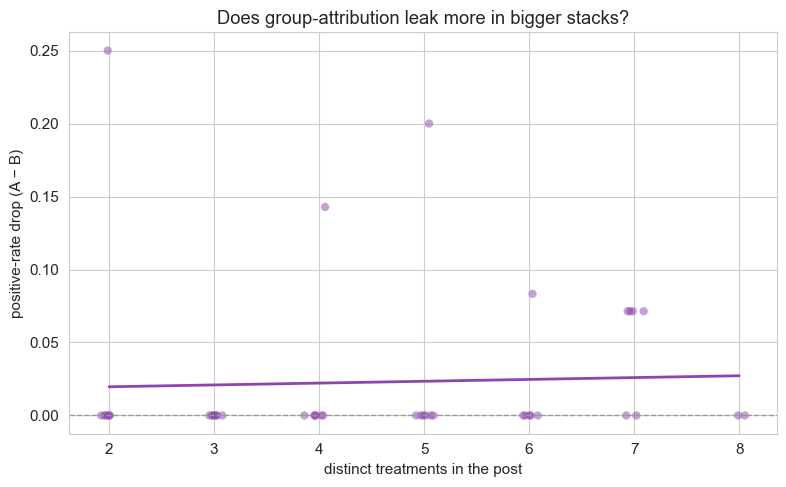

**What this shows:** Spearman ρ = 0.24 (p = 0.12) between stack size and the positive-rate drop. Of the 15 discordant pairs pooled, **12** lost a positive call under strict attribution and **3** gained one — the asymmetry is the inflation; the reverse flips (3) are cases where the strict wording nudged a borderline pair the other way, and are the honest noise floor of a one-line prompt change.

In [5]:

# Effect vs stack size: per-post drop in positive rate against n_treatments.
per_post = (pairs.groupby(["sample_id","n_treatments"])
            .apply(lambda g: g.A_pos.mean() - g.B_pos.mean()).rename("drop").reset_index())
rho, prho = spearmanr(per_post["n_treatments"], per_post["drop"])
fig, ax = plt.subplots(figsize=(8,5))
jit = np.random.default_rng(0).normal(0, 0.06, len(per_post))
ax.scatter(per_post["n_treatments"]+jit, per_post["drop"], alpha=0.5, color="#8e44ad", edgecolor="none")
ax.axhline(0, color="#999", lw=1, ls="--")
if per_post["n_treatments"].nunique() > 1:
    z = np.polyfit(per_post["n_treatments"], per_post["drop"], 1)
    xg = np.linspace(per_post["n_treatments"].min(), per_post["n_treatments"].max(), 50)
    ax.plot(xg, np.polyval(z, xg), color="#8e44ad", lw=2)
ax.set_xlabel("distinct treatments in the post"); ax.set_ylabel("positive-rate drop (A − B)")
ax.set_title("Does group-attribution leak more in bigger stacks?")
fig.tight_layout(); plt.show()
_tot = int(POOL["b_lost"] + POOL["c_gained"])
display(Markdown(
  f"**What this shows:** Spearman ρ = {rho:.2f} (p = {prho:.2g}) between stack size and the "
  f"positive-rate drop. Of the {_tot} discordant pairs pooled, **{POOL['b_lost']}** lost a positive "
  f"call under strict attribution and **{POOL['c_gained']}** gained one — the asymmetry is the "
  f"inflation; the reverse flips ({POOL['c_gained']}) are cases where the strict wording nudged a "
  f"borderline pair the other way, and are the honest noise floor of a one-line prompt change."))


## 5. Conclusion & validation verdict

This is a measurement-validity result, tiered by strength of evidence.

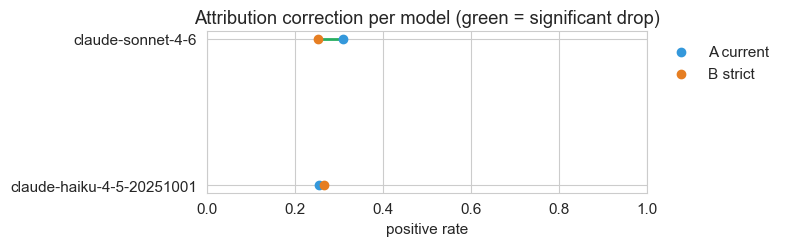

### Verdict

**Strong:** claude-sonnet-4-6 — significant positive-rate drop (n≥30, p<0.05), mean Δ 6%. Group-attribution inflation is real and sized.

**Implication:** the pipeline should adopt the per-drug attribution guard (or apply the measured correction) before per-treatment positive rates feed clustering — otherwise stacked posts inflate exactly the quantity we cluster on.

In [6]:

# Tiered verdict as a compact effect-size (drop) forest per model.
ms = model_stats.copy(); ms["label"] = ms["model"].map(lambda m: m.split("/")[-1])
fig, ax = plt.subplots(figsize=(8, 1.2+0.7*len(ms)))
for i, (_, r) in enumerate(ms.iterrows()):
    loA, hiA = wilson_ci(int(r.rate_A*r.n), int(r.n))
    loB, hiB = wilson_ci(int(r.rate_B*r.n), int(r.n))
    col = "#27ae60" if (r.p < 0.05 and r["drop"] > 0) else "#95a5a6"
    ax.plot([r.rate_B, r.rate_A], [i, i], color=col, lw=2)
    ax.scatter([r.rate_A],[i], color="#3498db", zorder=3, label="A current" if i==0 else "")
    ax.scatter([r.rate_B],[i], color="#e67e22", zorder=3, label="B strict" if i==0 else "")
ax.set_yticks(range(len(ms))); ax.set_yticklabels(ms["label"])
ax.set_xlabel("positive rate"); ax.set_xlim(0,1)
ax.set_title("Attribution correction per model (green = significant drop)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", frameon=False)
fig.tight_layout(); plt.show()

strong = ms[(ms.p<0.05) & (ms.n>=30) & (ms["drop"]>0)]
verdict = []
if len(strong):
    verdict.append(f"**Strong:** {', '.join(strong.label)} — significant positive-rate drop "
                   f"(n≥30, p<0.05), mean Δ {strong['drop'].mean():.0%}. Group-attribution inflation is real and sized.")
mod = ms[(ms.p<0.10) & ~ms.index.isin(strong.index) & (ms["drop"]>0)]
if len(mod):
    verdict.append(f"**Moderate:** {', '.join(mod.label)} — same direction, p<0.10.")
if not len(strong) and not len(mod):
    verdict.append("**Preliminary only:** no model reached significance at this sample size — "
                   "the direction is suggestive but underpowered; scale the run before acting.")
verdict.append("**Implication:** the pipeline should adopt the per-drug attribution guard (or apply "
               "the measured correction) before per-treatment positive rates feed clustering — "
               "otherwise stacked posts inflate exactly the quantity we cluster on.")
display(Markdown("### Verdict\n\n" + "\n\n".join(verdict)))


## 6. Research limitations

- **Validation-specific.** Variant B is *one* operationalization of "strict attribution"; a
  different wording could move the size (not, on this evidence, the direction). Two models and a
  40-post IRR slice — a smoke of the full design (roster × K=5 repeats). Numbers here size the
  effect; they do not yet nail its precision.
- **Sample window.** The IRR frame is 100–800-char posts — it excludes 42% of the corpus and the
  drug-denser long tail; the multi-treatment rate in the wild may differ.
- **The eight standard biases** apply to the underlying sentiment: selection (who posts),
  reporting, survivorship (recoverers leave), recall, confounding, no control group, sentiment ≠
  efficacy, and temporal snapshot. This notebook does not estimate treatment effects — only how a
  prompt rule moves a *measured* rate.
- **Pipeline biases:** positive is over-called ~10–20% (this test does not remove that; it removes
  the *stacking* component specifically), and group attribution is the very thing measured here.
- **Temperature 0** removes sampling noise but not all non-determinism (batching/float); a residual
  wobble is expected and is what the K=5 repeats (deferred) will quantify.

In [7]:

import hashlib as _h
_dbp = r"C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/patientpunk.db"
try:
    _sha = _h.sha256(open(_dbp,"rb").read()).hexdigest()[:16]
except Exception:
    _sha = "unavailable"
prov = pd.DataFrame({
    "item": ["j5 run generated (UTC)","models","temperature","max_upstream_depth",
             "posts / pairs","fixture","reference DB","DB sha256 (16)","skill version"],
    "value": [MANIFEST["generated_utc"], ", ".join(MANIFEST["models"]), MANIFEST["temperature"],
              MANIFEST["max_upstream_depth"], f'{MANIFEST["n_posts"]} / {len(pairs)} usable',
              MANIFEST["fixture"], "patientpunk.db", _sha, "research-assistant v2"],
})
display(HTML("<b>Provenance</b>" + prov.to_html(index=False)))
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1em">'
             'These findings reflect reporting patterns in online communities and the behaviour of '
             'a measurement pipeline, not population-level treatment effects. This is not medical advice.'
             '</div>'))


item,value
j5 run generated (UTC),2026-07-17T21:43:06.996309+00:00
models,"claude-sonnet-4-6, claude-haiku-4-5-20251001"
temperature,0.0
max_upstream_depth,2
posts / pairs,42 / 382 usable
fixture,f1_treatment_vocab.json
reference DB,patientpunk.db
DB sha256 (16),e3b0c44298fc1c14
skill version,research-assistant v2
